#  **Import Library**

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam


#  **Dataset Path**

In [30]:
# Path dataset
dataset_path = '/kaggle/input/covid-pneumonia-normal-chest-xray-images/'

#  **Dataset Exploration**

# 1. Jumlah Gambar Tiap Kelas

In [31]:
# Fungsi untuk menghitung jumlah gambar dalam setiap folder
def count_images_per_folder(path):
    folder_counts = {}
    for folder_name in os.listdir(path):
        folder_path = os.path.join(path, folder_name)
        if os.path.isdir(folder_path):
            num_images = len([f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))])
            folder_counts[folder_name] = num_images
    return folder_counts

# Hitung jumlah gambar per folder
folder_counts = count_images_per_folder(dataset_path)
print("Jumlah gambar per folder:")
for folder, count in folder_counts.items():
    print(f"{folder}: {count}")


Jumlah gambar per folder:
PNEUMONIA: 1800
NORMAL: 1802
COVID: 1626


# 2. Visualisasi Distribusi per Kelas

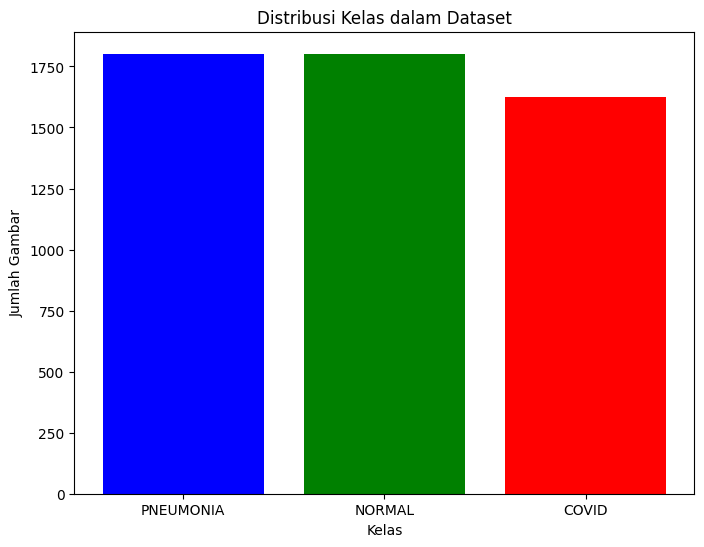

In [32]:
# Visualisasi distribusi kelas dalam bar chart
plt.figure(figsize=(8, 6))
plt.bar(folder_counts.keys(), folder_counts.values(), color=['blue', 'green', 'red'])
plt.title("Distribusi Kelas dalam Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()


# 3. Menampilkan Gambar per Kelas

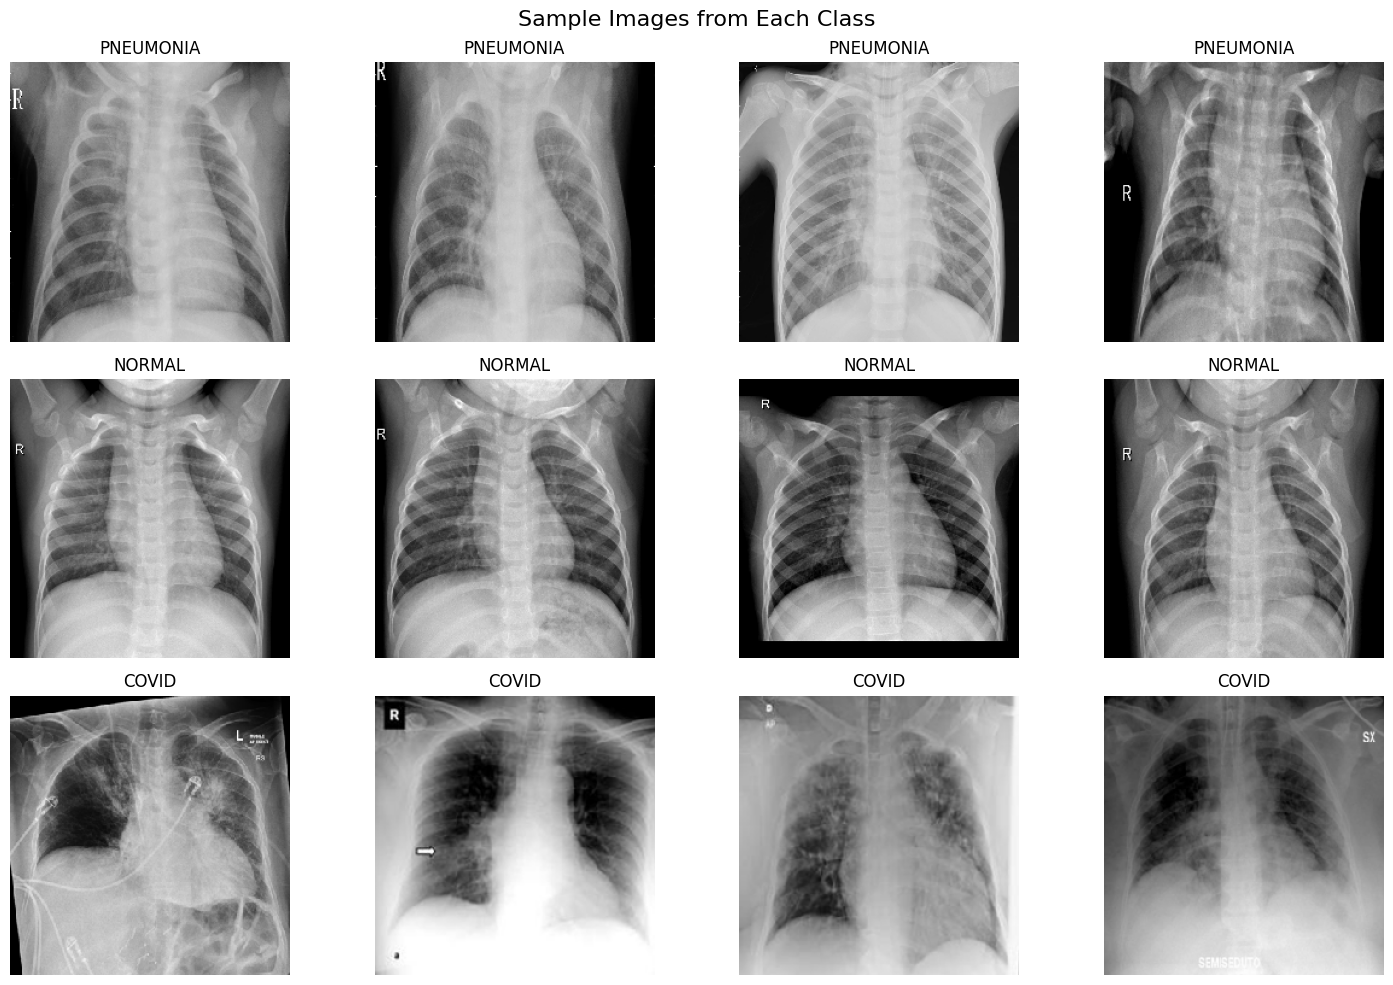

In [33]:
# Fungsi untuk menampilkan beberapa contoh gambar per folder
def show_sample_images(path, num_samples=4):
    fig, axes = plt.subplots(len(os.listdir(path)), num_samples, figsize=(15, 10))
    fig.suptitle("Sample Images from Each Class", fontsize=16)
    
    for i, folder_name in enumerate(os.listdir(path)):
        folder_path = os.path.join(path, folder_name)
        if os.path.isdir(folder_path):
            image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
            sample_files = random.sample(image_files, min(num_samples, len(image_files)))
            
            for j, image_file in enumerate(sample_files):
                image_path = os.path.join(folder_path, image_file)
                img = cv2.imread(image_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display
                axes[i, j].imshow(img)
                axes[i, j].axis('off')
                axes[i, j].set_title(f"{folder_name}")
    
    plt.tight_layout()
    plt.show()

# Menampilkan contoh gambar
show_sample_images(dataset_path, num_samples=4)


# **Data Preparation**

# 1. Resizing

In [34]:
img_size = (224, 224)
batch_size = 128

# 2. Data Augmentation for Training Set

In [35]:
# Data Augmentation untuk training set
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisasi pixel [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)


# 3. Data Augmentation fo Validation Set

In [36]:
# Data Augmentation untuk validation set
val_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalisasi pixel
    validation_split=0.2  # 20% untuk validation
)


# 4. Load Training Data

In [37]:
# Load training data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # 80% untuk training
)


Found 4183 images belonging to 3 classes.


# 5. Load Validation Data

In [38]:
# Load validation data
validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # 20% untuk validation
)


Found 1045 images belonging to 3 classes.


# **Model Implementation**

# 1. Parameters

In [39]:
# Parameters
epochs = 100

# 2. Load Pretrained Model

In [40]:
# Load pretrained InceptionV3 tanpa fully connected layer
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=img_size + (3,))

# Unfreeze beberapa layer terakhir dari base model
for layer in base_model.layers[-10:]:
    layer.trainable = True

# 3. Build Model 

In [41]:
# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),        # Pooling layer untuk meratakan fitur
    Dense(256, activation='relu'),   # Fully connected layer dengan 256 neuron
    Dropout(0.5),                    # Dropout untuk mencegah overfitting
    Dense(256, activation='relu'),   # Layer tambahan
    Dropout(0.5),                    # Dropout tambahan
    Dense(3, activation='softmax')   # Output layer (3 classes: COVID, PNEUMONIA, NORMAL)
])

# Compile model dengan learning rate yang lebih rendah untuk fine-tuning
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Callback

In [42]:
# Custom callback untuk menghitung precision, recall, dan F1-score
class MetricsCallback(Callback):
    def __init__(self, validation_generator):
        super().__init__()
        self.validation_generator = validation_generator
        self.precision = []
        self.recall = []
        self.f1 = []

    def on_epoch_end(self, epoch, logs=None):
        val_labels = []
        val_preds = []

        # Mendapatkan label dan prediksi pada data validasi
        for i in range(len(self.validation_generator)):
            x, y = self.validation_generator[i]
            val_labels.extend(np.argmax(y, axis=1))
            preds = np.argmax(self.model.predict(x), axis=1)
            val_preds.extend(preds)

        # Menghitung precision, recall, dan F1-score
        precision = precision_score(val_labels, val_preds, average='weighted')
        recall = recall_score(val_labels, val_preds, average='weighted')
        f1 = f1_score(val_labels, val_preds, average='weighted')

        self.precision.append(precision)
        self.recall.append(recall)
        self.f1.append(f1)

        print(f"Epoch {epoch + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
        
        # Update model checkpoint jika F1-score lebih baik
        if f1 > max(self.f1, default=0):
            self.model.save('inceptionv3_best_model_f1.keras')  # Menyimpan model dengan F1-score terbaik

# Callbacks: early stopping, model checkpoint, reduce learning rate on plateau, dan metrics
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
metrics_callback = MetricsCallback(validation_generator)

# 5. Train Model

In [43]:
# Train model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr, metrics_callback]
)

print("Model training selesai dan disimpan sebagai inceptionv3_best_model_f1.keras")

Epoch 1/100


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.5882 - loss: 0.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Epoch 1 - Precision: 0.7744, Recall: 0.6450, F1-score: 0.5364
33/33 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.5929 - loss: 0.8443 - val_accuracy: 0.6450 - val_loss: 2.0167 - learning_rate: 1.0000e-04
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9406 - loss: 0.1
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Epoch 2 - Precision: 0.8607, Recall: 0.

# **Evaluation**

# 1. Accuracy Plot

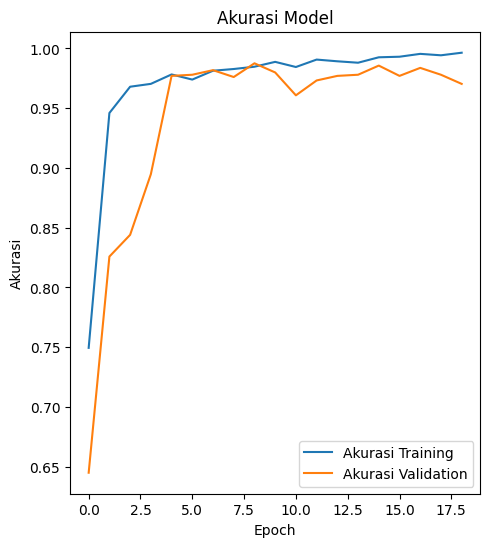

In [44]:
plt.figure(figsize=(18, 6))

# Plot akurasi training dan validation
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validation')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

plt.show()

# 2. Loss Plot

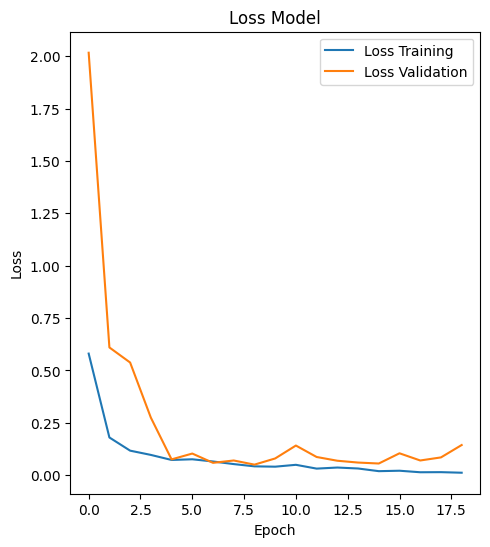

In [45]:
plt.figure(figsize=(18, 6))

# Plot loss training dan validation
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 3. F1-Score Plot 

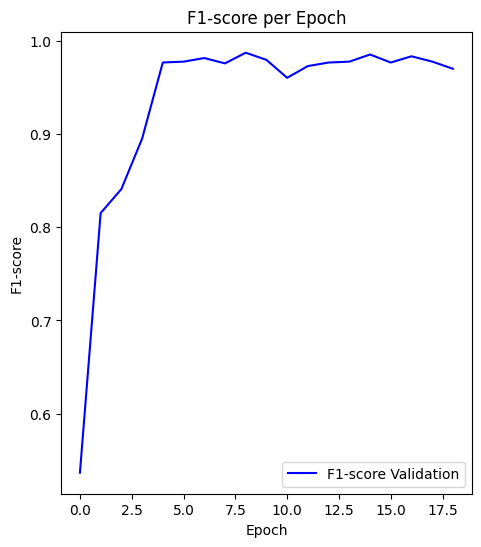

In [46]:
plt.figure(figsize=(18, 6))

# Plot F1-score
plt.subplot(1, 3, 3)
plt.plot(metrics_callback.f1, label='F1-score Validation', color='blue')
plt.title('F1-score per Epoch')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()

plt.show()

# 4. Best Result

In [47]:
# Evaluasi model pada data validasi
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Loss pada data validasi: {val_loss:.4f}")
print(f"Akurasi pada data validasi: {val_accuracy:.4f}")

# Tampilkan F1-score terbaik pada akhir pelatihan
best_f1 = max(metrics_callback.f1)
best_f1_epoch = metrics_callback.f1.index(best_f1) + 1
print(f"F1-score terbaik: {best_f1:.4f} pada epoch {best_f1_epoch}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 375ms/step - accuracy: 0.9880 - loss: 0.0524
Loss pada data validasi: 0.0502
Akurasi pada data validasi: 0.9876
F1-score terbaik: 0.9875 pada epoch 9


In [48]:
model_path = '/kaggle/working/model.keras'
model.save(model_path)